# 07 - Intersection Forms Explained

In 4D topology, the **Intersection Form** is arguably the most powerful invariant we have. For a closed, oriented 4-manifold $M$, it is a symmetric bilinear form on the second homology group:
$$Q_M: H_2(M; \mathbb{Z}) \times H_2(M; \mathbb{Z}) \to \mathbb{Z}$$
Freedman's theorem tells us that for simply connected 4-manifolds, the intersection form almost completely determines the homeomorphism type.

## Learning Goals
- **Understand Q_M**: Learn the definition and properties (Rank, Signature, Parity).
- **Canonical Examples**: Explore the forms of $S^2 \times S^2$, $\mathbb{CP}^2$, and the $E8$ manifold.
- **Classification**: Use `classify_z_form` to extract invariants for topological decision-making.
- **Visualizing Forms**: Represent intersection matrices and their spectral (eigenvalue) signatures.
- **Freedman's Theorem**: Build intuition for how forms map to manifolds.

## Formal Grounding

### The Triple Invariant (r, s, p)
An intersection form is characterized by:
1. **Rank (r)**: The dimension of $H_2(M; \mathbb{Z})$.
2. **Signature (s)**: The number of positive eigenvalues minus the number of negative eigenvalues.
3. **Parity/Type (p)**: 
   - **Type II (Even)**: If $Q(x, x) \in 2\mathbb{Z}$ for all $x$.
   - **Type I (Odd)**: Otherwise.

| Manifold | Matrix | Rank | Signature | Type |
|---|---|---|---|---|
| **$S^2 \times S^2$** | $\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ | 2 | 0 | II (Even) |
| **$\mathbb{CP}^2$** | $\begin{pmatrix} 1 \end{pmatrix}$ | 1 | 1 | I (Odd) |
| **$E8$ manifold**| $E_8$ matrix | 8 | 8 | II (Even) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysurgery.core.intersection_forms import IntersectionForm

print('=' * 70)
print('07 - Intersection Forms: Setup Complete')
print('=' * 70)

07 - Intersection Forms: Setup Complete


## Part 1: Canonical 4-Manifolds and their Matrices

We start by manually constructing the intersection forms for standard 4-manifolds and analyzing their invariants.


### Example 7.1: The Form of $S^2 \times S^2$ (Hyperbolic Plane)

In [2]:
# S2 x S2 is represented by the hyperbolic matrix H
matrix_h = np.array([
    [0, 1],
    [1, 0]
])
q_h = IntersectionForm(matrix=matrix_h, dimension=4)

info = q_h.classify_z_form()
print('S2 x S2 (Hyperbolic Form):')
print(f'  Rank: {info["rank"]}')
print(f'  Signature: {info["signature"]}')
print(f'  Type: {info["type"]} (Even: {info["even"]})')

S2 x S2 (Hyperbolic Form):
  Rank: 2
  Signature: 0
  Type: II (Even: True)


### Example 7.2: $\mathbb{CP}^2$ and $\overline{\mathbb{CP}^2}$

In [3]:
# CP2 has rank 1, signature 1
q_cp2 = IntersectionForm(matrix=np.array([[1]]), dimension=4)
# CP2-bar is the same manifold with reversed orientation
q_cp2_bar = IntersectionForm(matrix=np.array([[-1]]), dimension=4)

print(f'CP2: Rank={q_cp2.rank()}, Sig={q_cp2.signature()}, Type={q_cp2.type()}')
print(f'CP2-bar: Rank={q_cp2_bar.rank()}, Sig={q_cp2_bar.signature()}, Type={q_cp2_bar.type()}')

CP2: Rank=1, Sig=1, Type=I
CP2-bar: Rank=1, Sig=-1, Type=I


### Example 7.3: The E8 Manifold

In [4]:
# The E8 matrix is a classic even, definite form of rank 8
matrix_e8 = np.array([
    [2, 0, -1, 0, 0, 0, 0, 0],
    [0, 2, 0, -1, 0, 0, 0, 0],
    [-1, 0, 2, -1, 0, 0, 0, 0],
    [0, -1, -1, 2, -1, 0, 0, 0],
    [0, 0, 0, -1, 2, -1, 0, 0],
    [0, 0, 0, 0, -1, 2, -1, 0],
    [0, 0, 0, 0, 0, -1, 2, -1],
    [0, 0, 0, 0, 0, 0, -1, 2]
])
q_e8 = IntersectionForm(matrix=matrix_e8, dimension=4)

print('E8 Manifold:')
print(f'  Rank: {q_e8.rank()}')
print(f'  Signature: {q_e8.signature()}')
print(f'  Type: {q_e8.type()}')
print(f'  Is Indefinite? {q_e8.is_indefinite()}')

E8 Manifold:
  Rank: 8
  Signature: 8
  Type: II
  Is Indefinite? False


## Part 2: Freedman's Classification

For simply connected, smooth 4-manifolds, the intersection form is nearly everything. Over $\mathbb{Z}$, symmetric bilinear forms are classified by their rank, signature, and parity.


### Example 7.4: Indefinite vs Definite Analysis

In [5]:
# A form is indefinite if it has both positive and negative eigenvalues.
# Most "interesting" 4-manifolds in surgery are indefinite.
forms = {
    'S2 x S2': q_h,
    'E8': q_e8,
    'CP2 # CP2-bar': IntersectionForm(matrix=np.diag([1, -1]), dimension=4)
}

for name, q in forms.items():
    print(f'{name:15} | Indefinite: {q.is_indefinite()}')

S2 x S2         | Indefinite: True
E8              | Indefinite: False
CP2 # CP2-bar   | Indefinite: True


### Example 7.5: Connect Sums ($M \# N$)

In [6]:
# The intersection form of a connected sum is the direct sum of matrices.
def connect_sum(q1, q2):
    new_matrix = np.block([
        [q1.matrix, np.zeros((q1.matrix.shape[0], q2.matrix.shape[0]))],
        [np.zeros((q2.matrix.shape[0], q1.matrix.shape[0])), q2.matrix]
    ])
    return IntersectionForm(matrix=new_matrix, dimension=4)

q_sum = connect_sum(q_cp2, q_cp2) # CP2 # CP2
print('CP2 # CP2 Invariants:')
print(f'  Rank: {q_sum.rank()}, Signature: {q_sum.signature()}, Type: {q_sum.type()}')

CP2 # CP2 Invariants:
  Rank: 2, Signature: 2, Type: I


## Part 3: Visualization of Intersection Matrices

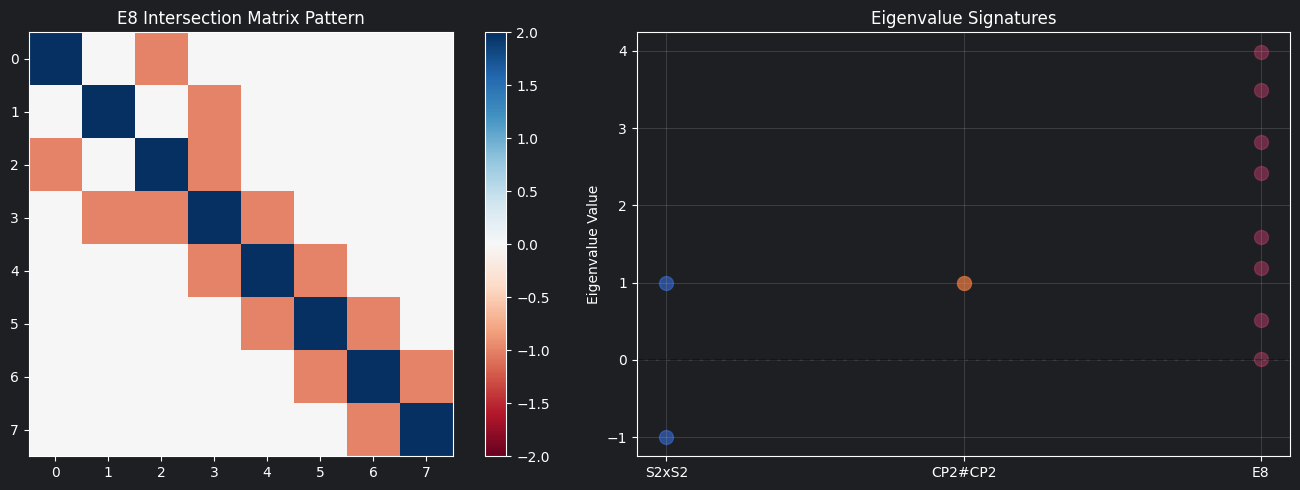

In [8]:
# Visualizing matrix entries and eigenvalue distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: E8 Matrix heat map
im = axes[0].imshow(matrix_e8, cmap='RdBu', vmin=-2, vmax=2)
axes[0].set_title('E8 Intersection Matrix Pattern')
fig.colorbar(im, ax=axes[0])

# Plot 2: Eigenvalues Comparison
labels = ['S2xS2', 'CP2#CP2', 'E8']
all_evals = [np.linalg.eigvalsh(m) for m in [matrix_h, np.diag([1, 1]), matrix_e8]]

for i, evals in enumerate(all_evals):
    axes[1].scatter([labels[i]]*len(evals), evals, s=100, alpha=0.6, label=labels[i])

axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_title('Eigenvalue Signatures')
axes[1].set_ylabel('Eigenvalue Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Failure Modes

1. **Non-Symmetric Matrices**: Intersection forms must be symmetric. Any skew-symmetry implies a different topological structure (like symplectic forms).
2. **Dimension Mismatch**: Trying to define an intersection form on an odd-dimensional manifold where $H_n$ interactions are skew-symmetric ($Q(x, y) = -Q(y, x)$).
3. **Floating Point Tolerance**: Near-zero eigenvalues can lead to incorrect signature calculations. `pySurgery` uses scale-aware tolerances to mitigate this.


In [ ]:
try:
    # Error: Not symmetric
    A_bad = np.array([[1, 2], [3, 1]])
    IntersectionForm(matrix=A_bad, dimension=4)
except Exception as e:
    print(f'Caught expected error: {e}')

## Summary Checklist
- [x] Defined intersection forms for canonical 4-manifolds.
- [x] Extracted Rank, Signature, and Parity using `classify_z_form`.
- [x] Distinguished between Type I (Odd) and Type II (Even) forms.
- [x] Visualized matrix patterns and spectral signatures.
- [x] Modeled Connected Sums of manifolds algebraically.

## Exercises
1. **The K3 Surface**: The K3 surface has a form $2(-E8) \oplus 3H$. Build its matrix and compute its rank and signature.
2. **Parity Check**: Find an integer matrix that has rank 2 and signature 0 but is Type I (Odd).
3. **Orientation reversal**: Prove that if $M$ has form $Q$, then $-M$ (reversed orientation) has form $-Q$.
4. **Unimodularity**: Compute the determinant of the $E8$ matrix. What does a determinant of 1 tell you about the manifold?
5. **Freedman Table**: Create a table of all possible unimodular forms of rank $\le 2$ and identify which manifolds they represent.

## Key Takeaways
- The **Intersection Form** is a complete invariant for simply connected 4-manifolds over $\mathbb{Z}$.
- **Rank and Signature** capture the size and "tilt" of the homology.
- **Parity** (Even/Odd) determines the fundamental behavior of characteristic classes.
- Connect sums of manifolds correspond directly to **Direct Sums** of their matrices.

**Ready for [08 - Quadratic Forms and Stabilization Patterns](./08_quadratic_forms_and_stabilization_patterns.ipynb)**
